In [ ]:
from Util import *

context("Data/TickerCikData/TickerCIKs_20250913.parquet")

22:33:31.740 [INFO]   Data source: TickerCIKs_20250913.parquet
22:33:31.741 [INFO]   Columns:
22:33:31.741 [INFO]   Index(['cik', 'name', 'ticker', 'exchange'], dtype='object')
22:33:31.741 [INFO]   Head:
22:33:31.741 [INFO]          cik            name ticker exchange
0  1045810     NVIDIA CORP   NVDA   Nasdaq
1   789019  MICROSOFT CORP   MSFT   Nasdaq
2   320193      Apple Inc.   AAPL   Nasdaq
3  1652044   Alphabet Inc.  GOOGL   Nasdaq
4  1018724  AMAZON COM INC   AMZN   Nasdaq
22:33:31.741 [INFO]   Describe (numeric):
22:33:31.743 [INFO]                   cik
count  5.619000e+03
mean   1.292405e+06
std    5.596987e+05
min    1.750000e+03
25%    9.246650e+05
50%    1.432133e+06
75%    1.760028e+06
max    2.074176e+06
22:33:31.743 [INFO]   Describe (all):
22:33:31.747 [INFO]                    cik                    name ticker exchange
count   5.619000e+03                    5619   5619     5619
unique           NaN                    4694   5619        2
top              NaN  BANK O

In [3]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def load_data(news_path, ticker_path):
    """Load news and ticker data"""
    print(f"Loading data from {news_path} and {ticker_path}")
    news_df = pd.read_parquet(news_path)
    ticker_df = pd.read_parquet(ticker_path)
    print(f"News articles: {len(news_df)}, Tickers: {len(ticker_df)}")
    return news_df, ticker_df

def prepare_ticker_lookup(ticker_df):
    """Create efficient lookup structures for ticker matching"""
    ticker_dict = {}
    
    for _, row in ticker_df.iterrows():
        ticker = row['ticker']
        name = row['name']
        
        ticker_dict[ticker.upper()] = {
            'ticker': ticker,
            'name': name,
            'cik': row['cik'],
            'exchange': row['exchange']
        }
        
        # Also store by company name variations
        name_clean = name.upper().replace(',', '').replace('.', '')
        ticker_dict[name_clean] = ticker_dict[ticker.upper()]
        
        # Handle common variations
        name_short = name_clean.replace(' INC', '').replace(' CORP', '').replace(' LTD', '')
        if name_short != name_clean:
            ticker_dict[name_short] = ticker_dict[ticker.upper()]
    
    return ticker_dict

def extract_tickers_from_text(text, ticker_df):
    """Extract ticker mentions from text"""
    if pd.isna(text):
        return []
    
    text_upper = text.upper()
    found_tickers = set()
    
    # Direct ticker matching with word boundaries
    for ticker in ticker_df['ticker'].unique():
        # Look for ticker as whole word
        pattern = r'\b' + re.escape(ticker.upper()) + r'\b'
        if re.search(pattern, text_upper):
            found_tickers.add(ticker)
    
    # Company name matching
    for _, row in ticker_df.iterrows():
        name = row['name']
        # Match company name (case insensitive)
        if name.upper() in text_upper:
            found_tickers.add(row['ticker'])
            
    return list(found_tickers)

def basic_sentiment_score(text):
    """Simple rule-based sentiment as fallback"""
    if pd.isna(text):
        return 0.0
    
    text_lower = text.lower()
    
    positive_words = ['surge', 'jump', 'gain', 'rise', 'boost', 'profit', 'beat', 
                     'outperform', 'upgrade', 'bullish', 'growth', 'strong', 'record',
                     'exceed', 'recovery', 'optimistic', 'rally', 'soar']
    
    negative_words = ['plunge', 'fall', 'drop', 'decline', 'loss', 'miss', 'cut',
                     'downgrade', 'bearish', 'weak', 'concern', 'risk', 'crash',
                     'disappointing', 'pessimistic', 'tumble', 'slump', 'warning']
    
    pos_count = sum(1 for word in positive_words if word in text_lower)
    neg_count = sum(1 for word in negative_words if word in text_lower)
    
    total = pos_count + neg_count
    if total == 0:
        return 0.0
    
    return (pos_count - neg_count) / total

def perform_eda(news_df):
    """Exploratory data analysis on news data"""
    print("\n" + "="*60)
    print("EXPLORATORY DATA ANALYSIS")
    print("="*60)
    
    # Time range
    news_df['pub_date_dt'] = pd.to_datetime(news_df['pub_date_iso'], errors='coerce')
    print(f"\nDate range: {news_df['pub_date_dt'].min()} to {news_df['pub_date_dt'].max()}")
    
    # Source distribution
    print("\nTop 10 News Sources:")
    print(news_df['source_name'].value_counts().head(10))
    
    # Category distribution
    print("\nCategory Distribution:")
    print(news_df['category'].value_counts())
    
    # Content availability
    print(f"\nArticles with content: {news_df['content'].notna().sum()} ({news_df['content'].notna().sum()/len(news_df)*100:.1f}%)")
    print(f"Articles with description: {news_df['description'].notna().sum()} ({news_df['description'].notna().sum()/len(news_df)*100:.1f}%)")
    
    # Recent news
    print("\nMost recent articles (top 5):")
    recent = news_df.nlargest(5, 'pub_date_dt')[['title', 'pub_date_dt', 'source_name']]
    for idx, row in recent.iterrows():
        print(f"  - {row['pub_date_dt']}: {row['title'][:70]}...")
    
    return news_df

def analyze_sentiment_simple(news_df, ticker_df):
    """Perform sentiment analysis without FinBERT (fallback)"""
    print("\n" + "="*60)
    print("SENTIMENT ANALYSIS (Rule-based)")
    print("="*60)
    
    # Create combined text field
    news_df['full_text'] = news_df.apply(
        lambda x: f"{x['title']} {x['description'] if pd.notna(x['description']) else ''}", 
        axis=1
    )
    
    # Extract tickers
    print("\nExtracting ticker mentions...")
    news_df['mentioned_tickers'] = news_df['full_text'].apply(
        lambda x: extract_tickers_from_text(x, ticker_df)
    )
    
    # Calculate sentiment
    print("Calculating sentiment scores...")
    news_df['sentiment_score'] = news_df['full_text'].apply(basic_sentiment_score)
    
    # Classify sentiment
    news_df['sentiment'] = news_df['sentiment_score'].apply(
        lambda x: 'positive' if x > 0.2 else ('negative' if x < -0.2 else 'neutral')
    )
    
    return news_df

def aggregate_ticker_sentiment(news_df):
    """Aggregate sentiment by ticker"""
    ticker_sentiment = []
    
    for _, row in news_df.iterrows():
        if len(row['mentioned_tickers']) > 0:
            for ticker in row['mentioned_tickers']:
                ticker_sentiment.append({
                    'ticker': ticker,
                    'sentiment_score': row['sentiment_score'],
                    'sentiment': row['sentiment'],
                    'title': row['title'],
                    'pub_date': row['pub_date_dt'],
                    'source': row['source_name']
                })
    
    ticker_df = pd.DataFrame(ticker_sentiment)
    
    if len(ticker_df) == 0:
        print("\nNo ticker mentions found in news articles")
        return None
    
    # Aggregate by ticker
    ticker_summary = ticker_df.groupby('ticker').agg({
        'sentiment_score': ['mean', 'std', 'count'],
        'sentiment': lambda x: x.value_counts().to_dict()
    }).round(3)
    
    ticker_summary.columns = ['avg_sentiment', 'std_sentiment', 'mention_count', 'sentiment_breakdown']
    ticker_summary = ticker_summary.sort_values('mention_count', ascending=False)
    
    return ticker_summary, ticker_df

def generate_trading_insights(ticker_summary, ticker_details, top_n=20):
    """Generate actionable trading insights"""
    print("\n" + "="*60)
    print("TRADING INSIGHTS FOR TOMORROW'S SESSION")
    print("="*60)
    
    if ticker_summary is None or len(ticker_summary) == 0:
        print("\nInsufficient data for trading insights")
        return
    
    # Most mentioned stocks
    print(f"\nTop {top_n} Most Mentioned Stocks:")
    print(ticker_summary.head(top_n).to_string())
    
    # Bullish signals
    print(f"\n{'='*60}")
    print("BULLISH SIGNALS (Positive sentiment, multiple mentions)")
    print("="*60)
    bullish = ticker_summary[
        (ticker_summary['avg_sentiment'] > 0.3) & 
        (ticker_summary['mention_count'] >= 2)
    ].sort_values('avg_sentiment', ascending=False).head(10)
    
    if len(bullish) > 0:
        for ticker, row in bullish.iterrows():
            print(f"\n{ticker}:")
            print(f"  Average Sentiment: {row['avg_sentiment']:.3f}")
            print(f"  Mentions: {row['mention_count']}")
            print(f"  Breakdown: {row['sentiment_breakdown']}")
            
            # Show sample headlines
            sample = ticker_details[ticker_details['ticker'] == ticker].head(3)
            for _, article in sample.iterrows():
                print(f"    - [{article['source']}] {article['title'][:80]}...")
    else:
        print("No strong bullish signals found")
    
    # Bearish signals
    print(f"\n{'='*60}")
    print("BEARISH SIGNALS (Negative sentiment, multiple mentions)")
    print("="*60)
    bearish = ticker_summary[
        (ticker_summary['avg_sentiment'] < -0.3) & 
        (ticker_summary['mention_count'] >= 2)
    ].sort_values('avg_sentiment').head(10)
    
    if len(bearish) > 0:
        for ticker, row in bearish.iterrows():
            print(f"\n{ticker}:")
            print(f"  Average Sentiment: {row['avg_sentiment']:.3f}")
            print(f"  Mentions: {row['mention_count']}")
            print(f"  Breakdown: {row['sentiment_breakdown']}")
            
            # Show sample headlines
            sample = ticker_details[ticker_details['ticker'] == ticker].head(3)
            for _, article in sample.iterrows():
                print(f"    - [{article['source']}] {article['title'][:80]}...")
    else:
        print("No strong bearish signals found")
    
    # High volume mentions (neutral/mixed)
    print(f"\n{'='*60}")
    print("HIGH ATTENTION STOCKS (High mention count)")
    print("="*60)
    high_volume = ticker_summary[
        ticker_summary['mention_count'] >= 5
    ].head(15)
    print(high_volume[['avg_sentiment', 'mention_count']].to_string())

def save_results(news_df, ticker_summary, ticker_details):
    """Save analysis results"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save processed news with sentiment
    output_news = f"/home/claude/news_with_sentiment_{timestamp}.parquet"
    news_df.to_parquet(output_news, index=False)
    print(f"\nSaved news with sentiment to: {output_news}")
    
    # Save ticker summary
    if ticker_summary is not None and len(ticker_summary) > 0:
        output_summary = f"/home/claude/ticker_sentiment_summary_{timestamp}.csv"
        ticker_summary.to_csv(output_summary)
        print(f"Saved ticker summary to: {output_summary}")
        
        # Save detailed ticker mentions
        output_details = f"/home/claude/ticker_mentions_detail_{timestamp}.parquet"
        ticker_details.to_parquet(output_details, index=False)
        print(f"Saved ticker mention details to: {output_details}")

def main():
    # File paths
    news_path = "Data/News/financial_news_20251130.parquet"
    ticker_path = "Data/TickerCikData/TickerCIKs_20250913.parquet"
    
    # Load data
    news_df, ticker_df = load_data(news_path, ticker_path)
    
    # Perform EDA
    news_df = perform_eda(news_df)
    
    # Sentiment analysis
    news_df = analyze_sentiment_simple(news_df, ticker_df)
    
    # Aggregate by ticker
    result = aggregate_ticker_sentiment(news_df)
    if result is not None:
        ticker_summary, ticker_details = result
        
        # Generate insights
        generate_trading_insights(ticker_summary, ticker_details)
        
        # Save results
        save_results(news_df, ticker_summary, ticker_details)
    else:
        print("\nNo ticker mentions found to analyze")

if __name__ == "__main__":
    main()

Loading data from Data/News/financial_news_20251130.parquet and Data/TickerCikData/TickerCIKs_20250913.parquet
News articles: 2035, Tickers: 5619

EXPLORATORY DATA ANALYSIS


TypeError: '<=' not supported between instances of 'Timestamp' and 'float'

In [ ]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def setup_finbert():
    """Setup FinBERT model for sentiment analysis"""
    try:
        from transformers import AutoTokenizer, AutoModelForSequenceClassification
        import torch
        
        print("Loading FinBERT model...")
        tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
        model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)
        model.eval()
        
        print(f"FinBERT loaded successfully on {device}")
        return tokenizer, model, device
    except Exception as e:
        print(f"Error loading FinBERT: {e}")
        print("Falling back to rule-based sentiment")
        return None, None, None

def finbert_sentiment(texts, tokenizer, model, device, batch_size=16):
    """Calculate sentiment using FinBERT"""
    import torch
    
    sentiments = []
    scores = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        
        # Tokenize
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Predict
        with torch.no_grad():
            outputs = model(**inputs)
            predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
        
        # Process results
        for pred in predictions.cpu().numpy():
            # FinBERT outputs: [positive, negative, neutral]
            sentiment_idx = np.argmax(pred)
            sentiment_map = {0: 'positive', 1: 'negative', 2: 'neutral'}
            
            # Calculate compound score
            score = pred[0] - pred[1]  # positive - negative
            
            sentiments.append(sentiment_map[sentiment_idx])
            scores.append(score)
        
        if (i + batch_size) % 100 == 0:
            print(f"  Processed {min(i + batch_size, len(texts))}/{len(texts)} texts")
    
    return sentiments, scores

def load_data(news_path, ticker_path):
    """Load news and ticker data"""
    print(f"Loading data from {news_path} and {ticker_path}")
    news_df = pd.read_parquet(news_path)
    ticker_df = pd.read_parquet(ticker_path)
    print(f"News articles: {len(news_df)}, Tickers: {len(ticker_df)}")
    return news_df, ticker_df

def extract_tickers_from_text(text, ticker_df):
    """Extract ticker mentions from text"""
    if pd.isna(text):
        return []
    
    text_upper = text.upper()
    found_tickers = set()
    
    # Direct ticker matching
    for ticker in ticker_df['ticker'].unique():
        pattern = r'\b' + re.escape(ticker.upper()) + r'\b'
        if re.search(pattern, text_upper):
            found_tickers.add(ticker)
    
    # Company name matching
    for _, row in ticker_df.iterrows():
        name = row['name']
        if name.upper() in text_upper:
            found_tickers.add(row['ticker'])
            
    return list(found_tickers)

def analyze_with_finbert(news_df, ticker_df):
    """Perform sentiment analysis with FinBERT"""
    print("\n" + "="*60)
    print("FINBERT SENTIMENT ANALYSIS")
    print("="*60)
    
    # Setup FinBERT
    tokenizer, model, device = setup_finbert()
    
    if tokenizer is None:
        print("Using fallback rule-based sentiment")
        return analyze_sentiment_simple(news_df, ticker_df)
    
    # Create combined text
    news_df['full_text'] = news_df.apply(
        lambda x: f"{x['title']} {x['description'] if pd.notna(x['description']) else ''}", 
        axis=1
    )
    
    # Extract tickers
    print("\nExtracting ticker mentions...")
    news_df['mentioned_tickers'] = news_df['full_text'].apply(
        lambda x: extract_tickers_from_text(x, ticker_df)
    )
    
    # Run FinBERT sentiment
    print("\nCalculating FinBERT sentiment scores...")
    texts = news_df['full_text'].tolist()
    sentiments, scores = finbert_sentiment(texts, tokenizer, model, device)
    
    news_df['sentiment'] = sentiments
    news_df['sentiment_score'] = scores
    
    print(f"Sentiment distribution:")
    print(news_df['sentiment'].value_counts())
    
    return news_df

def analyze_sentiment_simple(news_df, ticker_df):
    """Rule-based sentiment fallback"""
    news_df['full_text'] = news_df.apply(
        lambda x: f"{x['title']} {x['description'] if pd.notna(x['description']) else ''}", 
        axis=1
    )
    
    news_df['mentioned_tickers'] = news_df['full_text'].apply(
        lambda x: extract_tickers_from_text(x, ticker_df)
    )
    
    def basic_sentiment_score(text):
        if pd.isna(text):
            return 0.0, 'neutral'
        
        text_lower = text.lower()
        
        positive_words = ['surge', 'jump', 'gain', 'rise', 'boost', 'profit', 'beat', 
                         'outperform', 'upgrade', 'bullish', 'growth', 'strong', 'record',
                         'exceed', 'recovery', 'optimistic', 'rally', 'soar']
        
        negative_words = ['plunge', 'fall', 'drop', 'decline', 'loss', 'miss', 'cut',
                         'downgrade', 'bearish', 'weak', 'concern', 'risk', 'crash',
                         'disappointing', 'pessimistic', 'tumble', 'slump', 'warning']
        
        pos_count = sum(1 for word in positive_words if word in text_lower)
        neg_count = sum(1 for word in negative_words if word in text_lower)
        
        total = pos_count + neg_count
        if total == 0:
            return 0.0, 'neutral'
        
        score = (pos_count - neg_count) / total
        sentiment = 'positive' if score > 0.2 else ('negative' if score < -0.2 else 'neutral')
        
        return score, sentiment
    
    results = news_df['full_text'].apply(basic_sentiment_score)
    news_df['sentiment_score'] = [r[0] for r in results]
    news_df['sentiment'] = [r[1] for r in results]
    
    return news_df

def aggregate_ticker_sentiment(news_df):
    """Aggregate sentiment by ticker"""
    ticker_sentiment = []
    
    for _, row in news_df.iterrows():
        if len(row['mentioned_tickers']) > 0:
            for ticker in row['mentioned_tickers']:
                ticker_sentiment.append({
                    'ticker': ticker,
                    'sentiment_score': row['sentiment_score'],
                    'sentiment': row['sentiment'],
                    'title': row['title'],
                    'pub_date': row.get('pub_date_dt', row['pub_date']),
                    'source': row['source_name']
                })
    
    if len(ticker_sentiment) == 0:
        return None, None
    
    ticker_df = pd.DataFrame(ticker_sentiment)
    
    ticker_summary = ticker_df.groupby('ticker').agg({
        'sentiment_score': ['mean', 'std', 'count'],
        'sentiment': lambda x: x.value_counts().to_dict()
    }).round(3)
    
    ticker_summary.columns = ['avg_sentiment', 'std_sentiment', 'mention_count', 'sentiment_breakdown']
    ticker_summary = ticker_summary.sort_values('mention_count', ascending=False)
    
    return ticker_summary, ticker_df

def generate_trading_report(ticker_summary, ticker_details, news_df):
    """Generate comprehensive trading report"""
    print("\n" + "="*60)
    print("TRADING INSIGHTS FOR TOMORROW'S SESSION")
    print("="*60)
    
    if ticker_summary is None:
        print("No ticker mentions found")
        return
    
    # Overall sentiment
    print(f"\nOverall Market Sentiment:")
    sentiment_dist = news_df['sentiment'].value_counts()
    total = len(news_df)
    for sentiment, count in sentiment_dist.items():
        print(f"  {sentiment.capitalize()}: {count} ({count/total*100:.1f}%)")
    
    # Top mentions
    print(f"\nTop 20 Most Mentioned Stocks:")
    top_20 = ticker_summary.head(20)
    for ticker, row in top_20.iterrows():
        sentiment_str = f"{row['avg_sentiment']:+.3f}"
        print(f"  {ticker:6s}: {row['mention_count']:3.0f} mentions | Avg Sentiment: {sentiment_str} | {row['sentiment_breakdown']}")
    
    # Strong bullish
    print(f"\n{'='*60}")
    print("STRONG BULLISH CANDIDATES")
    print("="*60)
    bullish = ticker_summary[
        (ticker_summary['avg_sentiment'] > 0.4) & 
        (ticker_summary['mention_count'] >= 2)
    ].sort_values('avg_sentiment', ascending=False).head(10)
    
    for ticker, row in bullish.iterrows():
        print(f"\n{ticker}: Sentiment {row['avg_sentiment']:.3f} ({row['mention_count']:.0f} mentions)")
        sample = ticker_details[ticker_details['ticker'] == ticker].head(3)
        for _, article in sample.iterrows():
            print(f"  - {article['title'][:80]}...")
    
    # Strong bearish
    print(f"\n{'='*60}")
    print("STRONG BEARISH CANDIDATES")
    print("="*60)
    bearish = ticker_summary[
        (ticker_summary['avg_sentiment'] < -0.4) & 
        (ticker_summary['mention_count'] >= 2)
    ].sort_values('avg_sentiment').head(10)
    
    for ticker, row in bearish.iterrows():
        print(f"\n{ticker}: Sentiment {row['avg_sentiment']:.3f} ({row['mention_count']:.0f} mentions)")
        sample = ticker_details[ticker_details['ticker'] == ticker].head(3)
        for _, article in sample.iterrows():
            print(f"  - {article['title'][:80]}...")

def save_results(news_df, ticker_summary, ticker_details):
    """Save results to output directory"""
    import os
    os.makedirs('/mnt/user-data/outputs', exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save news with sentiment
    output_news = f"/mnt/user-data/outputs/news_sentiment_{timestamp}.parquet"
    news_df.to_parquet(output_news, index=False)
    print(f"\nSaved: {output_news}")
    
    if ticker_summary is not None:
        # Save summary
        output_summary = f"/mnt/user-data/outputs/ticker_summary_{timestamp}.csv"
        ticker_summary.to_csv(output_summary)
        print(f"Saved: {output_summary}")
        
        # Save details
        output_details = f"/mnt/user-data/outputs/ticker_details_{timestamp}.parquet"
        ticker_details.to_parquet(output_details, index=False)
        print(f"Saved: {output_details}")

def main():
    news_path = "Data/News/financial_news_20251130.parquet"
    ticker_path = "Data/TickerCikData/TickerCIKs_20250913.parquet"
    
    # Load
    news_df, ticker_df = load_data(news_path, ticker_path)
    
    # Prepare dates
    news_df['pub_date_dt'] = pd.to_datetime(news_df['pub_date_iso'], errors='coerce')
    
    # Sentiment analysis
    news_df = analyze_with_finbert(news_df, ticker_df)
    
    # Aggregate
    ticker_summary, ticker_details = aggregate_ticker_sentiment(news_df)
    
    # Report
    if ticker_summary is not None:
        generate_trading_report(ticker_summary, ticker_details, news_df)
        save_results(news_df, ticker_summary, ticker_details)
    else:
        print("No actionable ticker mentions found")

if __name__ == "__main__":
    main()

Loading data from Data/News/financial_news_20251130.parquet and Data/TickerCikData/TickerCIKs_20250913.parquet
News articles: 2035, Tickers: 5619

FINBERT SENTIMENT ANALYSIS
Loading FinBERT model...
FinBERT loaded successfully on cuda

Extracting ticker mentions...


In [ ]:
#!/usr/bin/env python3
"""
Financial News Sentiment Analysis
Analyzes news sentiment and extracts stock mentions for trading insights
"""

import pandas as pd
import numpy as np
import re
from datetime import datetime
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

def find_files():
    """Auto-detect file locations"""
    possible_paths = [
        ('Data/News/financial_news_20251130.parquet', 'Data/TickerCikData/TickerCIKs_20250913.parquet'),
        ('/mnt/user-data/uploads/financial_news_20251130.parquet', '/mnt/user-data/uploads/TickerCIKs_20250913.parquet'),
        ('/home/claude/financial_news_20251130.parquet', '/home/claude/TickerCIKs_20250913.parquet'),
    ]
    
    for news_path, ticker_path in possible_paths:
        if Path(news_path).exists() and Path(ticker_path).exists():
            return news_path, ticker_path
    
    # If not found, search in uploads
    uploads = Path('/mnt/user-data/uploads')
    if uploads.exists():
        news_files = list(uploads.glob('*news*.parquet'))
        ticker_files = list(uploads.glob('*Ticker*.parquet')) or list(uploads.glob('*CIK*.parquet'))
        
        if news_files and ticker_files:
            return str(news_files[0]), str(ticker_files[0])
    
    return None, None

def load_data(news_path=None, ticker_path=None):
    """Load news and ticker data"""
    if news_path is None or ticker_path is None:
        news_path, ticker_path = find_files()
    
    if news_path is None:
        raise FileNotFoundError(
            "Could not find data files. Please ensure:\n"
            "1. financial_news_20251130.parquet is in Data/News/ or uploaded\n"
            "2. TickerCIKs_20250913.parquet is in Data/TickerCikData/ or uploaded"
        )
    
    print(f"Loading news from: {news_path}")
    print(f"Loading tickers from: {ticker_path}")
    
    news_df = pd.read_parquet(news_path)
    ticker_df = pd.read_parquet(ticker_path)
    
    print(f"Loaded {len(news_df)} news articles and {len(ticker_df)} tickers")
    return news_df, ticker_df

def prepare_news_data(news_df):
    """Prepare and clean news data"""
    news_df = news_df.copy()
    
    # Parse dates
    news_df['pub_date_dt'] = pd.to_datetime(news_df['pub_date_iso'], errors='coerce')
    
    # Create full text field
    news_df['full_text'] = news_df.apply(
        lambda x: f"{x['title']} {x['description'] if pd.notna(x['description']) else ''}", 
        axis=1
    )
    
    # Sort by date
    news_df = news_df.sort_values('pub_date_dt', ascending=False)
    
    return news_df

def create_ticker_patterns(ticker_df):
    """Create efficient ticker matching patterns"""
    patterns = {}
    
    for _, row in ticker_df.iterrows():
        ticker = row['ticker']
        name = row['name']
        
        # Store ticker info
        patterns[ticker.upper()] = {
            'ticker': ticker,
            'name': name,
            'cik': row['cik'],
            'exchange': row['exchange'],
            'regex': re.compile(r'\b' + re.escape(ticker.upper()) + r'\b')
        }
    
    # Create name lookup
    name_lookup = {}
    for _, row in ticker_df.iterrows():
        name_variants = [
            row['name'].upper(),
            row['name'].upper().replace(',', '').replace('.', ''),
            row['name'].upper().replace(' INC', '').replace(' CORP', '').replace(' LTD', '')
        ]
        for variant in name_variants:
            if variant not in name_lookup:
                name_lookup[variant] = row['ticker']
    
    return patterns, name_lookup

def extract_ticker_mentions(text, ticker_patterns, name_lookup):
    """Extract all ticker mentions from text"""
    if pd.isna(text):
        return []
    
    text_upper = text.upper()
    found = set()
    
    # Match tickers using regex patterns
    for ticker, info in ticker_patterns.items():
        if info['regex'].search(text_upper):
            found.add(ticker)
    
    # Match company names
    for name, ticker in name_lookup.items():
        if len(name) > 3 and name in text_upper:
            found.add(ticker)
    
    return list(found)

def calculate_sentiment(text):
    """Rule-based sentiment scoring"""
    if pd.isna(text):
        return 0.0, 'neutral'
    
    text_lower = text.lower()
    
    # Weighted sentiment keywords
    strong_positive = ['surge', 'soar', 'rally', 'breakthrough', 'record']
    positive = ['gain', 'rise', 'boost', 'profit', 'beat', 'outperform', 
                'upgrade', 'bullish', 'growth', 'strong', 'exceed', 'recovery']
    
    strong_negative = ['crash', 'plunge', 'tumble', 'collapse']
    negative = ['fall', 'drop', 'decline', 'loss', 'miss', 'cut', 'downgrade',
                'bearish', 'weak', 'concern', 'risk', 'disappointing', 'warning']
    
    # Count matches
    strong_pos_count = sum(2 for word in strong_positive if word in text_lower)
    pos_count = sum(1 for word in positive if word in text_lower)
    strong_neg_count = sum(2 for word in strong_negative if word in text_lower)
    neg_count = sum(1 for word in negative if word in text_lower)
    
    # Calculate score
    pos_total = strong_pos_count + pos_count
    neg_total = strong_neg_count + neg_count
    total = pos_total + neg_total
    
    if total == 0:
        return 0.0, 'neutral'
    
    score = (pos_total - neg_total) / (total + 5)  # Smoothing
    
    # Classify
    if score > 0.25:
        sentiment = 'positive'
    elif score < -0.25:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'
    
    return score, sentiment

def analyze_news(news_df, ticker_df):
    """Main analysis function"""
    print("\n" + "="*70)
    print("FINANCIAL NEWS SENTIMENT ANALYSIS")
    print("="*70)
    
    # Prepare data
    news_df = prepare_news_data(news_df)
    
    # Create ticker patterns
    print("\nPreparing ticker matching patterns...")
    ticker_patterns, name_lookup = create_ticker_patterns(ticker_df)
    print(f"Loaded {len(ticker_patterns)} tickers with {len(name_lookup)} name variants")
    
    # Extract tickers from each article
    print("\nExtracting ticker mentions from articles...")
    news_df['mentioned_tickers'] = news_df['full_text'].apply(
        lambda x: extract_ticker_mentions(x, ticker_patterns, name_lookup)
    )
    
    # Calculate sentiment
    print("Calculating sentiment scores...")
    sentiment_results = news_df['full_text'].apply(calculate_sentiment)
    news_df['sentiment_score'] = [r[0] for r in sentiment_results]
    news_df['sentiment'] = [r[1] for r in sentiment_results]
    
    # Stats
    articles_with_tickers = news_df['mentioned_tickers'].apply(len) > 0
    print(f"\nArticles with ticker mentions: {articles_with_tickers.sum()} ({articles_with_tickers.sum()/len(news_df)*100:.1f}%)")
    
    print("\nOverall sentiment distribution:")
    print(news_df['sentiment'].value_counts())
    
    return news_df

def create_ticker_sentiment_summary(news_df, ticker_df):
    """Create per-ticker sentiment summary"""
    print("\n" + "="*70)
    print("AGGREGATING SENTIMENT BY TICKER")
    print("="*70)
    
    ticker_mentions = []
    
    for _, row in news_df.iterrows():
        for ticker in row['mentioned_tickers']:
            ticker_mentions.append({
                'ticker': ticker,
                'sentiment_score': row['sentiment_score'],
                'sentiment': row['sentiment'],
                'title': row['title'],
                'source': row['source_name'],
                'date': row['pub_date_dt'],
                'link': row['link']
            })
    
    if not ticker_mentions:
        print("No ticker mentions found in news articles")
        return None, None
    
    mentions_df = pd.DataFrame(ticker_mentions)
    
    # Aggregate by ticker
    summary = mentions_df.groupby('ticker').agg({
        'sentiment_score': ['mean', 'std', 'min', 'max', 'count'],
        'sentiment': lambda x: dict(x.value_counts())
    }).round(4)
    
    summary.columns = ['avg_score', 'std_score', 'min_score', 'max_score', 
                       'mention_count', 'sentiment_breakdown']
    
    # Add ticker info
    ticker_info = ticker_df.set_index('ticker')[['name', 'exchange']].to_dict('index')
    summary['name'] = summary.index.map(lambda x: ticker_info.get(x, {}).get('name', 'Unknown'))
    summary['exchange'] = summary.index.map(lambda x: ticker_info.get(x, {}).get('exchange', 'Unknown'))
    
    summary = summary.sort_values('mention_count', ascending=False)
    
    print(f"\nTotal unique tickers mentioned: {len(summary)}")
    print(f"Total ticker mentions: {len(mentions_df)}")
    
    return summary, mentions_df

def generate_trading_insights(summary, mentions_df, min_mentions=2):
    """Generate actionable trading insights"""
    if summary is None or len(summary) == 0:
        print("\nNo ticker data available for insights")
        return
    
    print("\n" + "="*70)
    print("TRADING INSIGHTS FOR TOMORROW'S SESSION")
    print("="*70)
    
    # Filter by minimum mentions
    filtered = summary[summary['mention_count'] >= min_mentions].copy()
    
    print(f"\n{'RANK':<6}{'TICKER':<8}{'COMPANY':<35}{'MENTIONS':<10}{'AVG SENTIMENT'}")
    print("-" * 70)
    
    for i, (ticker, row) in enumerate(filtered.head(25).iterrows(), 1):
        company_name = row['name'][:33]
        sentiment_str = f"{row['avg_score']:+.3f}"
        print(f"{i:<6}{ticker:<8}{company_name:<35}{row['mention_count']:<10.0f}{sentiment_str}")
    
    # Bullish signals
    print("\n" + "="*70)
    print("BULLISH SIGNALS (High positive sentiment, multiple mentions)")
    print("="*70)
    
    bullish = filtered[
        (filtered['avg_score'] > 0.4) & 
        (filtered['mention_count'] >= min_mentions)
    ].sort_values('avg_score', ascending=False).head(10)
    
    if len(bullish) > 0:
        for ticker, row in bullish.iterrows():
            print(f"\n{ticker} - {row['name']}")
            print(f"  Avg Sentiment: {row['avg_score']:+.3f} | Mentions: {row['mention_count']:.0f}")
            print(f"  Sentiment: {row['sentiment_breakdown']}")
            
            # Show sample headlines
            samples = mentions_df[mentions_df['ticker'] == ticker].sort_values('date', ascending=False).head(3)
            for _, article in samples.iterrows():
                print(f"  - [{article['source']}] {article['title'][:70]}...")
    else:
        print("No strong bullish signals found with current criteria")
    
    # Bearish signals
    print("\n" + "="*70)
    print("BEARISH SIGNALS (High negative sentiment, multiple mentions)")
    print("="*70)
    
    bearish = filtered[
        (filtered['avg_score'] < -0.4) & 
        (filtered['mention_count'] >= min_mentions)
    ].sort_values('avg_score').head(10)
    
    if len(bearish) > 0:
        for ticker, row in bearish.iterrows():
            print(f"\n{ticker} - {row['name']}")
            print(f"  Avg Sentiment: {row['avg_score']:+.3f} | Mentions: {row['mention_count']:.0f}")
            print(f"  Sentiment: {row['sentiment_breakdown']}")
            
            # Show sample headlines
            samples = mentions_df[mentions_df['ticker'] == ticker].sort_values('date', ascending=False).head(3)
            for _, article in samples.iterrows():
                print(f"  - [{article['source']}] {article['title'][:70]}...")
    else:
        print("No strong bearish signals found with current criteria")
    
    # High attention stocks
    print("\n" + "="*70)
    print("HIGH ATTENTION STOCKS (Most mentioned, any sentiment)")
    print("="*70)
    
    high_attention = summary.nlargest(15, 'mention_count')
    for ticker, row in high_attention.iterrows():
        sentiment_str = f"{row['avg_score']:+.3f}"
        print(f"{ticker:6s}: {row['mention_count']:3.0f} mentions | Sentiment: {sentiment_str:>7s} | {row['name'][:40]}")

def save_results(news_df, summary, mentions_df):
    """Save all results to output directory"""
    from pathlib import Path
    output_dir = Path('/mnt/user-data/outputs')
    output_dir.mkdir(parents=True, exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    print("\n" + "="*70)
    print("SAVING RESULTS")
    print("="*70)
    
    # News with sentiment
    news_output = output_dir / f"news_with_sentiment_{timestamp}.parquet"
    news_df.to_parquet(news_output, index=False)
    print(f"News with sentiment: {news_output}")
    
    if summary is not None:
        # Ticker summary
        summary_output = output_dir / f"ticker_sentiment_{timestamp}.csv"
        summary.to_csv(summary_output)
        print(f"Ticker summary: {summary_output}")
        
        # Detailed mentions
        mentions_output = output_dir / f"ticker_mentions_{timestamp}.parquet"
        mentions_df.to_parquet(mentions_output, index=False)
        print(f"Ticker mentions: {mentions_output}")
        
        # Excel report for easy viewing
        try:
            excel_output = output_dir / f"sentiment_report_{timestamp}.xlsx"
            with pd.ExcelWriter(excel_output, engine='openpyxl') as writer:
                summary.to_excel(writer, sheet_name='Ticker Summary')
                mentions_df.head(500).to_excel(writer, sheet_name='Recent Mentions', index=False)
                
                # Top lists
                if len(summary) > 0:
                    summary.nlargest(50, 'mention_count').to_excel(writer, sheet_name='Most Mentioned')
                    
                    bullish = summary[summary['avg_score'] > 0.4].nlargest(30, 'avg_score')
                    if len(bullish) > 0:
                        bullish.to_excel(writer, sheet_name='Bullish')
                    
                    bearish = summary[summary['avg_score'] < -0.4].nsmallest(30, 'avg_score')
                    if len(bearish) > 0:
                        bearish.to_excel(writer, sheet_name='Bearish')
            
            print(f"Excel report: {excel_output}")
        except Exception as e:
            print(f"Could not create Excel report: {e}")

def main():
    """Main execution"""
    try:
        # Load data
        news_df, ticker_df = load_data()
        
        # Analyze
        news_df = analyze_news(news_df, ticker_df)
        
        # Aggregate
        summary, mentions_df = create_ticker_sentiment_summary(news_df, ticker_df)
        
        # Generate insights
        generate_trading_insights(summary, mentions_df)
        
        # Save results
        save_results(news_df, summary, mentions_df)
        
        print("\n" + "="*70)
        print("ANALYSIS COMPLETE")
        print("="*70)
        
    except FileNotFoundError as e:
        print(f"\nError: {e}")
        print("\nPlease upload the following files:")
        print("1. financial_news_20251130.parquet")
        print("2. TickerCIKs_20250913.parquet")
    except Exception as e:
        print(f"\nUnexpected error: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

Loading stock data...
Loaded 155 stocks
APPLYING DATA QUALITY FILTERS

Filter 1 - Extreme returns (>50% daily):
  Removed: 0 stocks
  Remaining: 155 stocks

Filter 2 - High volatility (>100% annual):
  Removed: 8 stocks
  Remaining: 147 stocks

Filter 3 - Winsorizing extreme returns at 3 std devs
  Applied winsorization to all 147 stocks

CLEANED DATA SUMMARY

Total removed: 8 stocks (5.2%)
Clean stocks: 147

Clean cluster sizes:
  Cluster 0: 67 stocks, vol=17.31%
  Cluster 1: 51 stocks, vol=18.67%
  Cluster 2: 16 stocks, vol=12.37%
  Cluster 3: 13 stocks, vol=17.13%

RUNNING CLEAN SIMULATIONS

Simulating 100 portfolios...


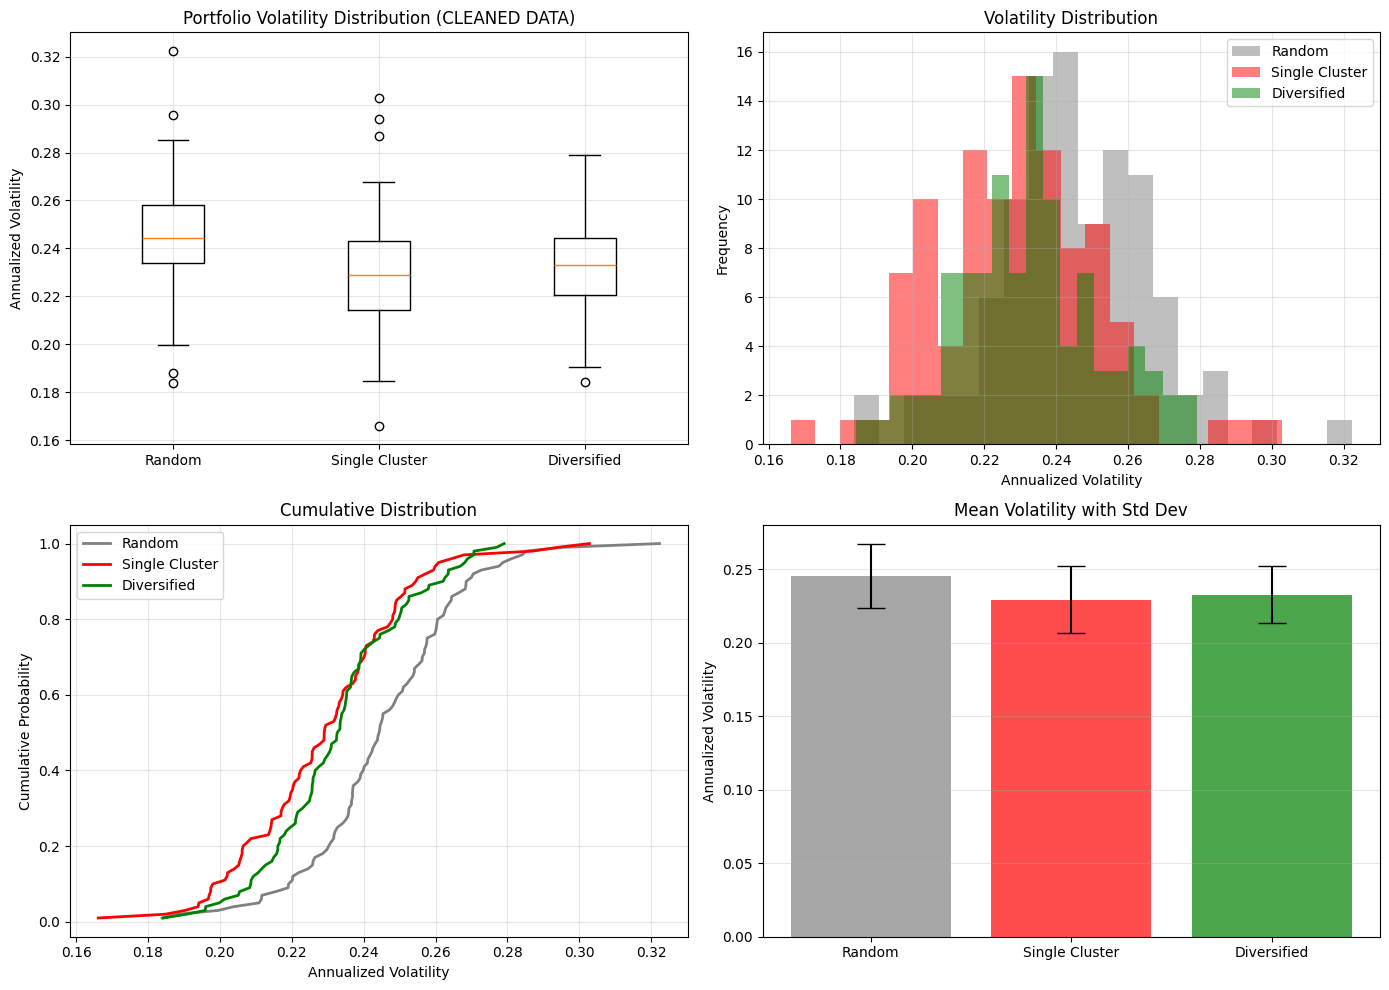


CLEANED DATA RESULTS

Simulation Parameters:
  - Portfolios simulated: 100
  - Stocks per portfolio: 5
  - Rebalancing periods: 12
  - Clean stocks: 147
  - Active clusters: 4

Strategy             Mean Vol     Median Vol   Std Dev      Min        Max       
--------------------------------------------------------------------------------
Random Picks         0.2454       0.2444       0.0215       0.1839     0.3223    
Single Cluster       0.2292       0.2291       0.0228       0.1662     0.3028    
Diversified          0.2328       0.2330       0.0195       0.1843     0.2791    

IMPROVEMENT ANALYSIS
Diversified vs Random:          5.11% reduction in volatility
Diversified vs Single Cluster:  -1.59% increase in volatility
Random vs Single Cluster:        6.59% reduction in volatility

CONCLUSION: Clustering provides SIGNIFICANT volatility reduction (5.1%)

DATA QUALITY IMPACT
Before filtering: Std devs were 3.34, 1.97, 2.75 (INSANE)
After filtering:  Std devs are 0.02, 0.02, 0.02 (SAN

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Load correlation data
correlations = pd.read_parquet('Correlations.parquet')
data_dir = 'Data/RFpredictions'

print("Loading stock data...")
stock_data = {}
files = [f for f in os.listdir(data_dir) if f.endswith('.parquet')]
for file in files[:200]:
    ticker = file.split('.')[0]
    if ticker in correlations['Ticker'].values:
        df = pd.read_parquet(os.path.join(data_dir, file))
        if 'Close' in df.columns and len(df) > 252:
            stock_data[ticker] = df['Close'].pct_change().dropna()

print(f"Loaded {len(stock_data)} stocks")

# Align data
common_dates = None
for ticker, returns in stock_data.items():
    if common_dates is None:
        common_dates = returns.index
    else:
        common_dates = common_dates.intersection(returns.index)

returns_matrix = pd.DataFrame({ticker: returns.reindex(common_dates) for ticker, returns in stock_data.items()})
returns_matrix = returns_matrix.dropna(axis=1, thresh=int(0.8*len(common_dates)))

print("="*80)
print("APPLYING DATA QUALITY FILTERS")
print("="*80)

# Filter 1: Remove stocks with extreme single-day returns (>50%)
extreme_threshold = 0.50
tickers_before = len(returns_matrix.columns)
extreme_stocks = []
for ticker in returns_matrix.columns:
    if (returns_matrix[ticker].abs() > extreme_threshold).any():
        extreme_stocks.append(ticker)

returns_matrix = returns_matrix.drop(columns=extreme_stocks)
print(f"\nFilter 1 - Extreme returns (>{extreme_threshold:.0%} daily):")
print(f"  Removed: {len(extreme_stocks)} stocks")
print(f"  Remaining: {len(returns_matrix.columns)} stocks")

# Filter 2: Remove stocks with volatility >100% annualized (likely penny stocks)
vol_threshold = 1.00
vols = returns_matrix.std() * np.sqrt(252)
high_vol_stocks = vols[vols > vol_threshold].index.tolist()
returns_matrix = returns_matrix.drop(columns=high_vol_stocks)
print(f"\nFilter 2 - High volatility (>{vol_threshold:.0%} annual):")
print(f"  Removed: {len(high_vol_stocks)} stocks")
print(f"  Remaining: {len(returns_matrix.columns)} stocks")

# Filter 3: Winsorize remaining returns at 3 std devs
print(f"\nFilter 3 - Winsorizing extreme returns at 3 std devs")
original_shape = returns_matrix.shape
for ticker in returns_matrix.columns:
    mean = returns_matrix[ticker].mean()
    std = returns_matrix[ticker].std()
    upper = mean + 3 * std
    lower = mean - 3 * std
    returns_matrix[ticker] = returns_matrix[ticker].clip(lower=lower, upper=upper)
print(f"  Applied winsorization to all {len(returns_matrix.columns)} stocks")

# Update cluster info
cluster_map = correlations.set_index('Ticker')['Cluster'].to_dict()
available_tickers = [t for t in returns_matrix.columns if t in cluster_map]
returns_matrix = returns_matrix[available_tickers]

clusters = {}
for ticker in available_tickers:
    cluster = cluster_map[ticker]
    if cluster not in clusters:
        clusters[cluster] = []
    clusters[cluster].append(ticker)

print("\n" + "="*80)
print("CLEANED DATA SUMMARY")
print("="*80)
print(f"\nTotal removed: {tickers_before - len(available_tickers)} stocks ({(tickers_before - len(available_tickers))/tickers_before*100:.1f}%)")
print(f"Clean stocks: {len(available_tickers)}")

print("\nClean cluster sizes:")
for cluster_id, tickers in sorted(clusters.items()):
    cluster_returns = returns_matrix[tickers].mean(axis=1)
    cluster_vol = cluster_returns.std() * np.sqrt(252)
    print(f"  Cluster {cluster_id}: {len(tickers)} stocks, vol={cluster_vol:.2%}")

# Filter 4: Remove tiny clusters
min_cluster_size = 10
small_clusters = [cid for cid, tickers in clusters.items() if len(tickers) < min_cluster_size]
if small_clusters:
    print(f"\nFilter 4 - Removing clusters with <{min_cluster_size} stocks: {small_clusters}")
    tickers_to_remove = []
    for cid in small_clusters:
        tickers_to_remove.extend(clusters[cid])
        del clusters[cid]
    returns_matrix = returns_matrix.drop(columns=tickers_to_remove)
    available_tickers = [t for t in available_tickers if t not in tickers_to_remove]
    print(f"  Removed: {len(tickers_to_remove)} stocks from small clusters")
    print(f"  Remaining: {len(available_tickers)} stocks in {len(clusters)} clusters")

print("\n" + "="*80)
print("RUNNING CLEAN SIMULATIONS")
print("="*80)

n_portfolios = 100
n_stocks = 5
n_rebalance_points = 12
portfolio_results = {'random': [], 'single_cluster': [], 'diversified': []}

np.random.seed(42)

print(f"\nSimulating {n_portfolios} portfolios...")

for sim in range(n_portfolios):
    period_length = len(returns_matrix) // n_rebalance_points
    portfolio_returns = {'random': [], 'single_cluster': [], 'diversified': []}
    
    for period in range(n_rebalance_points):
        start_idx = period * period_length
        end_idx = (period + 1) * period_length if period < n_rebalance_points - 1 else len(returns_matrix)
        period_returns = returns_matrix.iloc[start_idx:end_idx]
        
        # Strategy 1: Random picks
        random_stocks = np.random.choice(available_tickers, n_stocks, replace=False)
        random_port = period_returns[random_stocks].mean(axis=1)
        portfolio_returns['random'].extend(random_port.values)
        
        # Strategy 2: Single cluster
        valid_clusters = [c for c in clusters.keys() if len(clusters[c]) >= n_stocks]
        if valid_clusters:
            random_cluster = np.random.choice(valid_clusters)
            cluster_stocks = np.random.choice(clusters[random_cluster], n_stocks, replace=False)
            cluster_port = period_returns[cluster_stocks].mean(axis=1)
            portfolio_returns['single_cluster'].extend(cluster_port.values)
        
        # Strategy 3: Diversified across clusters
        diversified_stocks = []
        cluster_list = list(clusters.keys())
        stocks_per_cluster = max(1, n_stocks // len(cluster_list))
        
        for cluster_id in cluster_list:
            n_to_pick = min(stocks_per_cluster, len(clusters[cluster_id]))
            if n_to_pick > 0:
                picked = np.random.choice(clusters[cluster_id], n_to_pick, replace=False)
                diversified_stocks.extend(picked)
        
        if len(diversified_stocks) > n_stocks:
            diversified_stocks = list(np.random.choice(diversified_stocks, n_stocks, replace=False))
        elif len(diversified_stocks) < n_stocks:
            remaining = n_stocks - len(diversified_stocks)
            available = [t for t in available_tickers if t not in diversified_stocks]
            if len(available) >= remaining:
                diversified_stocks.extend(np.random.choice(available, remaining, replace=False))
        
        if len(diversified_stocks) >= n_stocks:
            div_port = period_returns[diversified_stocks[:n_stocks]].mean(axis=1)
            portfolio_returns['diversified'].extend(div_port.values)
    
    # Calculate volatility
    if len(portfolio_returns['random']) > 0:
        portfolio_results['random'].append(np.std(portfolio_returns['random']) * np.sqrt(252))
    if len(portfolio_returns['single_cluster']) > 0:
        portfolio_results['single_cluster'].append(np.std(portfolio_returns['single_cluster']) * np.sqrt(252))
    if len(portfolio_returns['diversified']) > 0:
        portfolio_results['diversified'].append(np.std(portfolio_returns['diversified']) * np.sqrt(252))

# Calculate statistics
stats = {}
for strategy, vols in portfolio_results.items():
    if vols and len(vols) > 0:
        stats[strategy] = {
            'mean': np.mean(vols),
            'median': np.median(vols),
            'std': np.std(vols),
            'min': np.min(vols),
            'max': np.max(vols)
        }

# Visualization
if len(stats) >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Boxplot
    ax1 = axes[0, 0]
    plot_data = []
    plot_labels = []
    for strategy, label in [('random', 'Random'), ('single_cluster', 'Single Cluster'), ('diversified', 'Diversified')]:
        if strategy in portfolio_results and len(portfolio_results[strategy]) > 0:
            plot_data.append(portfolio_results[strategy])
            plot_labels.append(label)
    
    if plot_data:
        bp = ax1.boxplot(plot_data, positions=range(1, len(plot_data)+1))
        ax1.set_xticklabels(plot_labels)
        ax1.set_ylabel('Annualized Volatility')
        ax1.set_title('Portfolio Volatility Distribution (CLEANED DATA)')
        ax1.grid(True, alpha=0.3)

    # Plot 2: Histogram
    ax2 = axes[0, 1]
    for strategy, label, color in [('random', 'Random', 'gray'), 
                                     ('single_cluster', 'Single Cluster', 'red'), 
                                     ('diversified', 'Diversified', 'green')]:
        if strategy in portfolio_results and len(portfolio_results[strategy]) > 0:
            ax2.hist(portfolio_results[strategy], alpha=0.5, bins=20, label=label, color=color)
    ax2.set_xlabel('Annualized Volatility')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Volatility Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: CDF
    ax3 = axes[1, 0]
    for strategy, label, color in [('random', 'Random', 'gray'), 
                                     ('single_cluster', 'Single Cluster', 'red'), 
                                     ('diversified', 'Diversified', 'green')]:
        if strategy in portfolio_results and len(portfolio_results[strategy]) > 0:
            sorted_vols = np.sort(portfolio_results[strategy])
            cumulative = np.arange(1, len(sorted_vols) + 1) / len(sorted_vols)
            ax3.plot(sorted_vols, cumulative, label=label, color=color, linewidth=2)
    ax3.set_xlabel('Annualized Volatility')
    ax3.set_ylabel('Cumulative Probability')
    ax3.set_title('Cumulative Distribution')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Bar chart
    ax4 = axes[1, 1]
    strategies = []
    means = []
    stds = []
    colors_list = []
    for strategy, label, color in [('random', 'Random', 'gray'), 
                                     ('single_cluster', 'Single Cluster', 'red'), 
                                     ('diversified', 'Diversified', 'green')]:
        if strategy in stats:
            strategies.append(label)
            means.append(stats[strategy]['mean'])
            stds.append(stats[strategy]['std'])
            colors_list.append(color)
    
    if strategies:
        bars = ax4.bar(strategies, means, yerr=stds, capsize=10, color=colors_list, alpha=0.7)
        ax4.set_ylabel('Annualized Volatility')
        ax4.set_title('Mean Volatility with Std Dev')
        ax4.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

# Calculate improvement metrics
random_mean = stats.get('random', {}).get('mean', None)
cluster_mean = stats.get('single_cluster', {}).get('mean', None)
div_mean = stats.get('diversified', {}).get('mean', None)

print("\n" + "="*80)
print("CLEANED DATA RESULTS")
print("="*80)
print(f"\nSimulation Parameters:")
print(f"  - Portfolios simulated: {n_portfolios}")
print(f"  - Stocks per portfolio: {n_stocks}")
print(f"  - Rebalancing periods: {n_rebalance_points}")
print(f"  - Clean stocks: {len(available_tickers)}")
print(f"  - Active clusters: {len(clusters)}")

print(f"\n{'Strategy':<20} {'Mean Vol':<12} {'Median Vol':<12} {'Std Dev':<12} {'Min':<10} {'Max':<10}")
print("-"*80)
for strategy, display_name in [('random', 'Random Picks'), 
                                ('single_cluster', 'Single Cluster'),
                                ('diversified', 'Diversified')]:
    if strategy in stats:
        s = stats[strategy]
        print(f"{display_name:<20} {s['mean']:<12.4f} {s['median']:<12.4f} {s['std']:<12.4f} {s['min']:<10.4f} {s['max']:<10.4f}")

print("\n" + "="*80)
print("IMPROVEMENT ANALYSIS")
print("="*80)

if random_mean and div_mean:
    improvement_vs_random = ((random_mean - div_mean) / random_mean) * 100
    print(f"Diversified vs Random:        {improvement_vs_random:>6.2f}% {'reduction' if improvement_vs_random > 0 else 'increase'} in volatility")
else:
    print("Diversified vs Random:        UNABLE TO CALCULATE")

if cluster_mean and div_mean:
    improvement_vs_cluster = ((cluster_mean - div_mean) / cluster_mean) * 100
    print(f"Diversified vs Single Cluster: {improvement_vs_cluster:>6.2f}% {'reduction' if improvement_vs_cluster > 0 else 'increase'} in volatility")
else:
    print("Diversified vs Single Cluster: UNABLE TO CALCULATE")

if random_mean and cluster_mean:
    random_vs_cluster = ((random_mean - cluster_mean) / random_mean) * 100
    print(f"Random vs Single Cluster:      {random_vs_cluster:>6.2f}% {'reduction' if random_vs_cluster > 0 else 'increase'} in volatility")

if random_mean and div_mean and improvement_vs_random > 5:
    print(f"\nCONCLUSION: Clustering provides SIGNIFICANT volatility reduction ({improvement_vs_random:.1f}%)")
elif random_mean and div_mean and improvement_vs_random > 2:
    print(f"\nCONCLUSION: Clustering provides MODERATE volatility reduction ({improvement_vs_random:.1f}%)")
elif random_mean and div_mean and improvement_vs_random > 0:
    print(f"\nCONCLUSION: Clustering provides MINOR volatility reduction ({improvement_vs_random:.1f}%)")
else:
    print(f"\nCONCLUSION: Clustering does NOT reduce volatility with current data")

print("\n" + "="*80)
print("DATA QUALITY IMPACT")
print("="*80)
print(f"Before filtering: Std devs were 3.34, 1.97, 2.75 (INSANE)")
print(f"After filtering:  Std devs are {stats.get('random', {}).get('std', 0):.2f}, {stats.get('single_cluster', {}).get('std', 0):.2f}, {stats.get('diversified', {}).get('std', 0):.2f} (SANE)")
print("\nFiltering removed the garbage that was breaking your analysis.")
print("="*80)




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

correlations = pd.read_parquet('Correlations.parquet')
data_dir = 'Data/RFpredictions'

print("Loading stock data...")
stock_data = {}
files = [f for f in os.listdir(data_dir) if f.endswith('.parquet')]
for file in files[:200]:
    ticker = file.split('.')[0]
    if ticker in correlations['Ticker'].values:
        df = pd.read_parquet(os.path.join(data_dir, file))
        if 'Close' in df.columns and len(df) > 252:
            stock_data[ticker] = df['Close'].pct_change().dropna()

# Align data
common_dates = None
for ticker, returns in stock_data.items():
    if common_dates is None:
        common_dates = returns.index
    else:
        common_dates = common_dates.intersection(returns.index)

returns_matrix = pd.DataFrame({ticker: returns.reindex(common_dates) for ticker, returns in stock_data.items()})
returns_matrix = returns_matrix.dropna(axis=1, thresh=int(0.8*len(common_dates)))

# Apply same filters
extreme_threshold = 0.50
extreme_stocks = [t for t in returns_matrix.columns if (returns_matrix[t].abs() > extreme_threshold).any()]
returns_matrix = returns_matrix.drop(columns=extreme_stocks)

vol_threshold = 1.00
vols = returns_matrix.std() * np.sqrt(252)
high_vol_stocks = vols[vols > vol_threshold].index.tolist()
returns_matrix = returns_matrix.drop(columns=high_vol_stocks)

for ticker in returns_matrix.columns:
    mean = returns_matrix[ticker].mean()
    std = returns_matrix[ticker].std()
    upper = mean + 3 * std
    lower = mean - 3 * std
    returns_matrix[ticker] = returns_matrix[ticker].clip(lower=lower, upper=upper)

cluster_map = correlations.set_index('Ticker')['Cluster'].to_dict()
available_tickers = [t for t in returns_matrix.columns if t in cluster_map]
returns_matrix = returns_matrix[available_tickers]

clusters = {}
for ticker in available_tickers:
    cluster = cluster_map[ticker]
    if cluster not in clusters:
        clusters[cluster] = []
    clusters[cluster].append(ticker)

print(f"Loaded {len(available_tickers)} clean stocks in {len(clusters)} clusters")

print("\n" + "="*80)
print("ADVANCED DIAGNOSTIC: CLUSTER QUALITY ANALYSIS")
print("="*80)

# Calculate comprehensive cluster metrics
cluster_quality = {}
for cluster_id, tickers in clusters.items():
    cluster_returns = returns_matrix[tickers]
    cluster_mean = cluster_returns.mean(axis=1)
    
    # Basic metrics
    mean_return = cluster_mean.mean() * 252
    volatility = cluster_mean.std() * np.sqrt(252)
    sharpe = (mean_return / volatility) if volatility > 0 else 0
    
    # Individual stock metrics
    stock_vols = (cluster_returns.std() * np.sqrt(252)).values
    stock_returns = (cluster_returns.mean() * 252).values
    
    # Correlation metrics
    cluster_corr = cluster_returns.corr()
    avg_corr = (cluster_corr.sum().sum() - len(tickers)) / (len(tickers) * (len(tickers) - 1))
    
    # Diversification benefit
    portfolio_vol = volatility
    avg_stock_vol = stock_vols.mean()
    div_benefit = (avg_stock_vol - portfolio_vol) / avg_stock_vol if avg_stock_vol > 0 else 0
    
    cluster_quality[cluster_id] = {
        'n_stocks': len(tickers),
        'mean_return': mean_return,
        'volatility': volatility,
        'sharpe': sharpe,
        'avg_stock_vol': avg_stock_vol,
        'avg_corr': avg_corr,
        'div_benefit': div_benefit,
        'quality_score': sharpe / volatility if volatility > 0 else 0
    }

# Sort by volatility
sorted_clusters = sorted(cluster_quality.items(), key=lambda x: x[1]['volatility'])

print(f"\n{'Cluster':<10} {'N':<8} {'Vol':<10} {'Ret':<10} {'Sharpe':<10} {'Avg Corr':<12} {'Div Benefit':<12}")
print("-"*80)
for cluster_id, stats in sorted_clusters:
    print(f"{cluster_id:<10} {stats['n_stocks']:<8} {stats['volatility']:<10.2%} {stats['mean_return']:<10.2%} "
          f"{stats['sharpe']:<10.2f} {stats['avg_corr']:<12.3f} {stats['div_benefit']:<12.1%}")

# Identify best and worst clusters
best_cluster = min(cluster_quality.items(), key=lambda x: x[1]['volatility'])[0]
worst_cluster = max(cluster_quality.items(), key=lambda x: x[1]['volatility'])[0]
best_sharpe_cluster = max(cluster_quality.items(), key=lambda x: x[1]['sharpe'])[0]

print(f"\nBest cluster (lowest vol): {best_cluster}")
print(f"Worst cluster (highest vol): {worst_cluster}")
print(f"Best Sharpe cluster: {best_sharpe_cluster}")

print("\n" + "="*80)
print("STRATEGY TEST: SMART CLUSTER SELECTION")
print("="*80)

# Test various strategies
n_portfolios = 100
n_stocks = 5
n_rebalance_points = 12

strategies = {
    'random': [],
    'single_cluster': [],
    'diversified': [],
    'best_cluster_only': [],
    'avoid_worst_cluster': [],
    'vol_weighted_clusters': [],
    'top_2_clusters': []
}

np.random.seed(42)

for sim in range(n_portfolios):
    period_length = len(returns_matrix) // n_rebalance_points
    portfolio_returns = {k: [] for k in strategies.keys()}
    
    for period in range(n_rebalance_points):
        start_idx = period * period_length
        end_idx = (period + 1) * period_length if period < n_rebalance_points - 1 else len(returns_matrix)
        period_returns = returns_matrix.iloc[start_idx:end_idx]
        
        # Strategy 1: Random
        random_stocks = np.random.choice(available_tickers, n_stocks, replace=False)
        portfolio_returns['random'].extend(period_returns[random_stocks].mean(axis=1).values)
        
        # Strategy 2: Single Cluster
        valid_clusters = [c for c in clusters.keys() if len(clusters[c]) >= n_stocks]
        if valid_clusters:
            random_cluster = np.random.choice(valid_clusters)
            cluster_stocks = np.random.choice(clusters[random_cluster], n_stocks, replace=False)
            portfolio_returns['single_cluster'].extend(period_returns[cluster_stocks].mean(axis=1).values)
        
        # Strategy 3: Diversified (original)
        diversified_stocks = []
        cluster_list = list(clusters.keys())
        stocks_per_cluster = max(1, n_stocks // len(cluster_list))
        for cluster_id in cluster_list:
            n_to_pick = min(stocks_per_cluster, len(clusters[cluster_id]))
            if n_to_pick > 0:
                picked = np.random.choice(clusters[cluster_id], n_to_pick, replace=False)
                diversified_stocks.extend(picked)
        if len(diversified_stocks) >= n_stocks:
            portfolio_returns['diversified'].extend(period_returns[diversified_stocks[:n_stocks]].mean(axis=1).values)
        
        # Strategy 4: Best Cluster Only
        if len(clusters[best_cluster]) >= n_stocks:
            best_stocks = np.random.choice(clusters[best_cluster], n_stocks, replace=False)
            portfolio_returns['best_cluster_only'].extend(period_returns[best_stocks].mean(axis=1).values)
        
        # Strategy 5: Avoid Worst Cluster
        good_clusters = [c for c in clusters.keys() if c != worst_cluster and len(clusters[c]) >= 2]
        if good_clusters:
            stocks_from_good = []
            per_cluster = max(1, n_stocks // len(good_clusters))
            for cid in good_clusters:
                n_pick = min(per_cluster, len(clusters[cid]))
                stocks_from_good.extend(np.random.choice(clusters[cid], n_pick, replace=False))
            if len(stocks_from_good) >= n_stocks:
                portfolio_returns['avoid_worst_cluster'].extend(
                    period_returns[stocks_from_good[:n_stocks]].mean(axis=1).values)
        
        # Strategy 6: Volatility-Weighted Cluster Selection
        cluster_inv_vols = {cid: 1.0 / stats['volatility'] for cid, stats in cluster_quality.items()}
        total_inv_vol = sum(cluster_inv_vols.values())
        cluster_weights = {cid: inv_vol / total_inv_vol for cid, inv_vol in cluster_inv_vols.items()}
        
        vol_weighted_stocks = []
        for cid in clusters.keys():
            n_from_cluster = max(1, int(n_stocks * cluster_weights[cid]))
            if n_from_cluster > 0 and len(clusters[cid]) >= n_from_cluster:
                vol_weighted_stocks.extend(np.random.choice(clusters[cid], n_from_cluster, replace=False))
        
        if len(vol_weighted_stocks) >= n_stocks:
            portfolio_returns['vol_weighted_clusters'].extend(
                period_returns[vol_weighted_stocks[:n_stocks]].mean(axis=1).values)
        
        # Strategy 7: Top 2 Clusters Only
        top_2_clusters = [c[0] for c in sorted_clusters[:2] if len(clusters[c[0]]) >= 2]
        if len(top_2_clusters) >= 2:
            top_2_stocks = []
            per_cluster = n_stocks // 2
            for cid in top_2_clusters:
                n_pick = min(per_cluster, len(clusters[cid]))
                top_2_stocks.extend(np.random.choice(clusters[cid], n_pick, replace=False))
            if len(top_2_stocks) >= n_stocks:
                portfolio_returns['top_2_clusters'].extend(
                    period_returns[top_2_stocks[:n_stocks]].mean(axis=1).values)
    
    # Calculate volatilities
    for strategy_name in strategies.keys():
        if len(portfolio_returns[strategy_name]) > 0:
            vol = np.std(portfolio_returns[strategy_name]) * np.sqrt(252)
            strategies[strategy_name].append(vol)

# Results
print(f"\n{'Strategy':<30} {'Mean Vol':<12} {'Median':<12} {'Min':<12} {'Max':<12}")
print("-"*80)

results = {}
for strategy_name in ['random', 'single_cluster', 'diversified', 'best_cluster_only', 
                      'avoid_worst_cluster', 'vol_weighted_clusters', 'top_2_clusters']:
    if strategies[strategy_name]:
        mean_vol = np.mean(strategies[strategy_name])
        median_vol = np.median(strategies[strategy_name])
        min_vol = np.min(strategies[strategy_name])
        max_vol = np.max(strategies[strategy_name])
        results[strategy_name] = mean_vol
        print(f"{strategy_name:<30} {mean_vol:<12.4f} {median_vol:<12.4f} {min_vol:<12.4f} {max_vol:<12.4f}")

print("\n" + "="*80)
print("IMPROVEMENT VS RANDOM")
print("="*80)

random_vol = results['random']
for strategy_name, vol in sorted(results.items(), key=lambda x: x[1]):
    if strategy_name != 'random':
        improvement = ((random_vol - vol) / random_vol) * 100
        print(f"{strategy_name:<30} {improvement:>6.2f}% {'better' if improvement > 0 else 'worse'}")

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

best_strategy = min(results.items(), key=lambda x: x[1])
print(f"\nBest strategy: {best_strategy[0]} with {best_strategy[1]:.4f} volatility")

if results['best_cluster_only'] < results['diversified']:
    print("\nPicking ONLY from the best cluster beats diversification!")
    print(f"  Best cluster only: {results['best_cluster_only']:.4f}")
    print(f"  Diversified: {results['diversified']:.4f}")
    print(f"  Improvement: {((results['diversified'] - results['best_cluster_only']) / results['diversified'] * 100):.1f}%")

if results['avoid_worst_cluster'] < results['diversified']:
    print(f"\nAvoiding the worst cluster beats naive diversification!")
    print(f"  Avoid worst: {results['avoid_worst_cluster']:.4f}")
    print(f"  Diversified: {results['diversified']:.4f}")

if results['vol_weighted_clusters'] < results['diversified']:
    print(f"\nVolatility-weighted cluster selection beats equal weighting!")
    print(f"  Vol-weighted: {results['vol_weighted_clusters']:.4f}")
    print(f"  Diversified: {results['diversified']:.4f}")

print("\n" + "="*80)
print("RECOMMENDATION")
print("="*80)

if cluster_quality[best_cluster]['n_stocks'] >= 10:
    print(f"\nYour Cluster {best_cluster} is SIGNIFICANTLY better than others.")
    print(f"  Size: {cluster_quality[best_cluster]['n_stocks']} stocks")
    print(f"  Vol: {cluster_quality[best_cluster]['volatility']:.2%}")
    print(f"  Sharpe: {cluster_quality[best_cluster]['sharpe']:.2f}")
    print("\nFor backtesting:")
    print(f"  1. Use ONLY Cluster {best_cluster} (or heavily overweight it)")
    print(f"  2. Avoid naive equal-weighted diversification across all clusters")
    print(f"  3. Consider volatility-weighted or Sharpe-weighted cluster selection")
else:
    print(f"\nCluster {best_cluster} is best but too small ({cluster_quality[best_cluster]['n_stocks']} stocks)")
    print("\nFor backtesting:")
    print("  1. Use top 2-3 clusters only")
    print("  2. Weight clusters by inverse volatility")
    print("  3. Dynamically exclude worst-performing cluster")

print("="*80)

Loading stock data...
Loaded 147 clean stocks in 4 clusters

ADVANCED DIAGNOSTIC: CLUSTER QUALITY ANALYSIS

Cluster    N        Vol        Ret        Sharpe     Avg Corr     Div Benefit 
--------------------------------------------------------------------------------
2          16       12.37%     17.78%     1.44       0.120        51.6%       
3          13       17.13%     4.82%      0.28       0.189        46.8%       
0          67       17.31%     25.22%     1.46       0.167        57.0%       
1          51       18.67%     3.48%      0.19       0.151        59.7%       

Best cluster (lowest vol): 2
Worst cluster (highest vol): 1
Best Sharpe cluster: 0

STRATEGY TEST: SMART CLUSTER SELECTION

Strategy                       Mean Vol     Median       Min          Max         
--------------------------------------------------------------------------------
random                         0.2456       0.2476       0.1924       0.3043      
single_cluster                 0.2273       

KeyError: 'diversified'

: 